# rliable comparison — interactive

Everything the `rliable_compare.py` CLI does, but broken into cells so you can
tweak one knob and re-run one figure instead of re-running the whole script.

**How to use it:** run cells 1–4 once (loading and bootstrapping is the slow
part), then live in section 5. Each figure cell is independent — edit a colour,
a size, a label, re-run that one cell.

If you change anything in `rliable_compare.py` itself, restart the kernel (or
run `importlib.reload(rc)`) to pick it up.

## 1. Setup

In [1]:
import sys, importlib
from pathlib import Path

# folder containing rliable_compare.py — "." if the notebook sits beside it
SCRIPT_DIR = Path(".").resolve()
sys.path.insert(0, str(SCRIPT_DIR))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from rliable import library as rly

import rliable_compare as rc
importlib.reload(rc)

# rc sets the Agg backend on import; switch back so figures show up inline
%matplotlib inline

print("loaded from", rc.__file__)

loaded from /home/rudra/Documents/rep_lr/rliable_compare.py


## 2. Configure

Every option here matches a CLI flag of the same name (`fig_width` is
`--fig-width`, and so on), so anything you settle on in the notebook transfers
straight to the command line.

In [22]:
args = rc.default_args(
    # ---- where the logs are ------------------------------------------------
    logs_dir="logs_fresh",      # root containing <Env>/<algo>/seed-*/progress.csv
    # envs=["all"],               # ["all"] or e.g. ["BallInCup", "CheetahRun"]
    envs = [ "BallInCup", "CartpoleBalanceSparse", "CartpoleSwingup", "CartpoleSwingupSparse", "CheetahRun", "FingerSpin", "FingerTurnEasy", "FingerTurnHard","FishSwim", "HopperHop", "HopperStand", "ReacherEasy", "ReacherHard", "WalkerRun", "WalkerStand", "WalkerWalk"],

    algos=["dhpg_fix2", "algo3"],   # ALSO sets display order: first = leftmost
                                    # in the legend, top row in the tables

    # ---- what to plot ------------------------------------------------------
    metric_col="Eval/Return",   # any column in progress.csv
    step_col="Train/Steps",
    max_score=1000.0,           # normaliser; 1000 = DMC max return
    final_window=5,             # average the last N evals as the final score
    smooth=3,                   # rolling-mean window for CURVES only (1 = off);
                                # never affects reported numbers
    drop_leading_zeros=False,   # strip placeholder zero rows before first eval
    max_steps=None,             # truncate all runs at this step count
    curve_points=101,           # resolution of the shared step grid

    # ---- statistics --------------------------------------------------------
    reps=2000,                  # bootstrap resamples; 2000 is fine while
                                # iterating, raise to 20000 for the final figures
    seed=0,

    # ---- naming and colour -------------------------------------------------
    labels={"algo3": "Ours", "dhpg_fix2": "DHPG"},
    color_overrides={"algo3": "#c0392b"},   # anything unset falls back to
                                            # rc.PALETTE in `algos` order

    # ---- figure geometry ---------------------------------------------------
    fig_width=5.5,              # text width in inches (5.5 for ICLR)
    font="sans",                # "sans" or "serif"
    font_size=11.0,
    grid_cols=4,                # panels per row in the per-environment grid
    panel_width=None,           # None = split fig_width across the columns
    panel_height=1.45,
    panel_pad=None,             # gap between panels, inches (None = ~0.04)
    margin_right=0.55,          # balances the y-label space on the left
    margin_left=0.0,

    # ---- output ------------------------------------------------------------
    out_dir="rliable_out",
    formats=["pdf"],
    dpi=400,
)

rc.setup_style(args)   # re-run this cell after changing font/size/colours
args

Namespace(logs_dir='logs_fresh', envs=['BallInCup', 'CartpoleBalanceSparse', 'CartpoleSwingup', 'CartpoleSwingupSparse', 'CheetahRun', 'FingerSpin', 'FingerTurnEasy', 'FingerTurnHard', 'FishSwim', 'HopperHop', 'HopperStand', 'ReacherEasy', 'ReacherHard', 'WalkerRun', 'WalkerStand', 'WalkerWalk'], algos=['dhpg_fix2', 'algo3'], step_col='Train/Steps', metric_col='Eval/Return', max_score=1000.0, final_window=5, max_steps=None, curve_points=101, smooth=3, drop_leading_zeros=False, reps=2000, seed=0, out_dir='rliable_out', label_pairs=[], color_pairs=[], fig_width=5.5, font='sans', font_size=11.0, grid_cols=4, panel_width=None, panel_height=1.45, panel_pad=None, margin_right=0.55, margin_left=0.0, formats=['pdf'], dpi=400, labels={'algo3': 'Ours', 'dhpg_fix2': 'DHPG'}, color_overrides={'algo3': '#c0392b'})

### Which columns are available?

Handy when you move on from `Eval/Return` to one of the representation metrics.

In [3]:
probe = next(Path(args.logs_dir).glob("*/*/seed-*/progress.csv"))
print(probe)
list(pd.read_csv(probe, nrows=1).columns)

logs_fresh/CartpoleBalanceSparse/algo4/seed-001-2026-09-05-02-27-57/progress.csv


['Train/Steps',
 'Loss/Loss_critic',
 'Loss/Loss_actor',
 'Loss/Loss_alpha',
 'Loss/Loss_state_action_metric',
 'Loss/Loss_state_metric',
 'Loss/Loss_state_action_to_state',
 'Loss/Act_rep_loss',
 'Loss/Critic_rep_loss',
 'SAC/Alpha',
 'SAC/LogPi_mean',
 'SAC/Q1_mean',
 'SAC/Q2_mean',
 'Norm/actor_model',
 'Norm/critic_model',
 'Norm/state_action_metric_model',
 'Norm/state_metric_model',
 'Norm/state_action_state_metric_model',
 'Metric/self_state_distance',
 'Metric/cross_state_distance',
 'Metric/self_state_action_distance',
 'Metric/cross_state_action_distance',
 'Metric/avg_self_state_asymmetry',
 'Metric/avg_cross_state_asymmetry',
 'Metric/avg_self_sa_asymmetry',
 'Metric/avg_cross_sa_asymmetry',
 'Metric/self_state_action_to_state_distance',
 'Metric/cross_state_action_to_state_distance',
 'Metric/h_lambda_diff_self',
 'Metric/h_lambda_diff_cross',
 'Eval/Return']

## 3. Load the runs

`discover` finds the run directories; `build_matrices` reads every
`progress.csv` and assembles the `(runs x tasks)` score matrix rliable wants.

In [4]:
tree = rc.discover(args.logs_dir, args.envs, args.algos)
for env in sorted(tree):
    for algo in sorted(tree[env]):
        print(f"{env:<18} {algo:<12} seeds: "
              + ", ".join(f"{s:03d}" for s in tree[env][algo]))

AcrobotSwingup     algo3        seeds: 000, 001, 002
AcrobotSwingup     dhpg_fix2    seeds: 000, 001, 002
AcrobotSwingupSparse algo3        seeds: 000, 001, 002
AcrobotSwingupSparse dhpg_fix2    seeds: 000, 001, 002
BallInCup          algo3        seeds: 000, 001, 002
BallInCup          dhpg_fix2    seeds: 000, 001, 002
CartpoleBalanceSparse algo3        seeds: 000, 001, 002
CartpoleBalanceSparse dhpg_fix2    seeds: 000, 001, 002
CartpoleSwingup    algo3        seeds: 000, 001, 002
CartpoleSwingup    dhpg_fix2    seeds: 000, 001, 002
CartpoleSwingupSparse algo3        seeds: 000, 001, 002
CartpoleSwingupSparse dhpg_fix2    seeds: 000, 001, 002
CheetahRun         algo3        seeds: 000, 001, 002
CheetahRun         dhpg_fix2    seeds: 000, 001, 002
FingerSpin         algo3        seeds: 000, 001, 002
FingerSpin         dhpg_fix2    seeds: 000, 001, 002
FingerTurnEasy     algo3        seeds: 000, 001, 002
FingerTurnEasy     dhpg_fix2    seeds: 000, 001, 002
FingerTurnHard     algo3      

In [5]:
final, curves, frames, tasks = rc.build_matrices(tree, args)

algos = list(final)                                    # display order
labels = {a: args.labels.get(a, a) for a in algos}
colors, markers = rc.style_map(algos, args)
tag = args.metric_col.split("/")[-1]

n_seeds = next(iter(final.values())).shape[0]
print(f"{n_seeds} runs x {len(tasks)} tasks, steps up to {frames[-1]:,.0f}")
if n_seeds * len(tasks) < 10:
    print("NOTE: few runs x tasks -> wide CIs, IQM close to a median.")

3 runs x 18 tasks, steps up to 5,000,192


In [6]:
# sanity check: per-run final scores in raw units
pd.DataFrame({
    labels[a]: final[a].mean(axis=0) * args.max_score for a in algos
}, index=tasks).round(1)

,DHPG,Ours
AcrobotSwingup,309.1,138.5
AcrobotSwingupSparse,15.2,0.8
BallInCup,323.5,964.4
CartpoleBalanceSparse,927.4,992.4
CartpoleSwingup,684.9,864.9
CartpoleSwingupSparse,421.0,735.2
CheetahRun,872.5,913.1
FingerSpin,948.5,864.4
FingerTurnEasy,910.6,878.6
FingerTurnHard,891.1,714.8


## 4. Bootstrap statistics

The slow cells. Run them once; the figure cells below reuse the results, so
restyling a plot costs nothing.

In [ ]:
np.random.seed(args.seed)
agg_scores, agg_cis = rly.get_interval_estimates(
    final, rc.aggregate_func, reps=args.reps)

pd.DataFrame(
    {labels[a]: [f"{agg_scores[a][k]:.3f} "
                 f"[{agg_cis[a][0, k]:.3f}, {agg_cis[a][1, k]:.3f}]"
                 for k in range(len(rc.AGG_NAMES))] for a in algos},
    index=rc.AGG_NAMES,
)

In [ ]:
# performance profile
lo = float(min(m.min() for m in final.values()))
hi = float(max(m.max() for m in final.values()))
taus = np.linspace(min(lo, 0.0), hi * 1.02 + 1e-8, 81)
prof, prof_cis = rly.create_performance_profile(final, taus, reps=args.reps)

# sample efficiency (IQM at each step)
iqm_scores, iqm_cis = rly.get_interval_estimates(
    curves, rc.iqm_over_frames, reps=max(args.reps // 10, 200))
print("done")

In [ ]:
# probability of improvement, for every ordered pair
poi_rows = []
if len(algos) >= 2:
    pairs = {f"{x},{y}": (final[x], final[y])
             for i, x in enumerate(algos) for y in algos[i + 1:]}
    poi, poi_cis = rly.get_interval_estimates(
        pairs, rc.metrics.probability_of_improvement, reps=args.reps)
    for key in pairs:
        x, y = key.split(",")
        ci = np.ravel(poi_cis[key])
        poi_rows.append(dict(x=x, y=y,
                             p_improvement=float(np.ravel(poi[key])[0]),
                             ci_low=float(ci[0]), ci_high=float(ci[1])))
        print(f"P({labels[x]} > {labels[y]}) = {poi_rows[-1]['p_improvement']:.3f} "
              f"[{ci[0]:.3f}, {ci[1]:.3f}]")

## 5. Figures

Tweak and re-run any single cell. Two ways to change the look:

* **per-figure** — edit the arguments in the cell, or the returned `fig`/`ax`
  directly (`fig.axes[0].set_xlim(...)`)
* **globally** — change `args` in section 2 and re-run `rc.setup_style(args)`,
  then re-run the figure cells

Nothing here writes to disk; section 6 does the saving.

In [ ]:
fig = rc.fig_aggregate_metrics(agg_scores, agg_cis, algos, labels,
                               colors, markers, args, tag)

In [ ]:
fig = rc.fig_sample_efficiency(frames, iqm_scores, iqm_cis, algos, labels,
                               colors, markers, args, tag)

# example of a one-off tweak that doesn't touch args:
# fig.axes[0].set_ylim(0, 1); fig.axes[0].legend(loc="lower right")

In [ ]:
fig = rc.fig_performance_profile(prof, prof_cis, taus, algos, labels,
                                 colors, markers, args, tag)

In [ ]:
fig = rc.fig_probability_of_improvement(poi_rows, labels, colors, markers, args)

### The per-environment grid

`rc.fig_grid` exposes every knob as a keyword argument, independent of `args`.
Keeping them in one `GRID` dict means the save cell in section 6 reproduces
exactly what you see here.

Sizing note: `panel_width`/`panel_height` set the *slot* each panel gets. Tick
labels and titles are drawn inside that slot, so the visible box is slightly
smaller. `extra_width`/`extra_height` are the allowances for the shared axis
labels and the legend; the final canvas is
`ncols*panel_width + extra_width` by `nrows*panel_height + extra_height`.

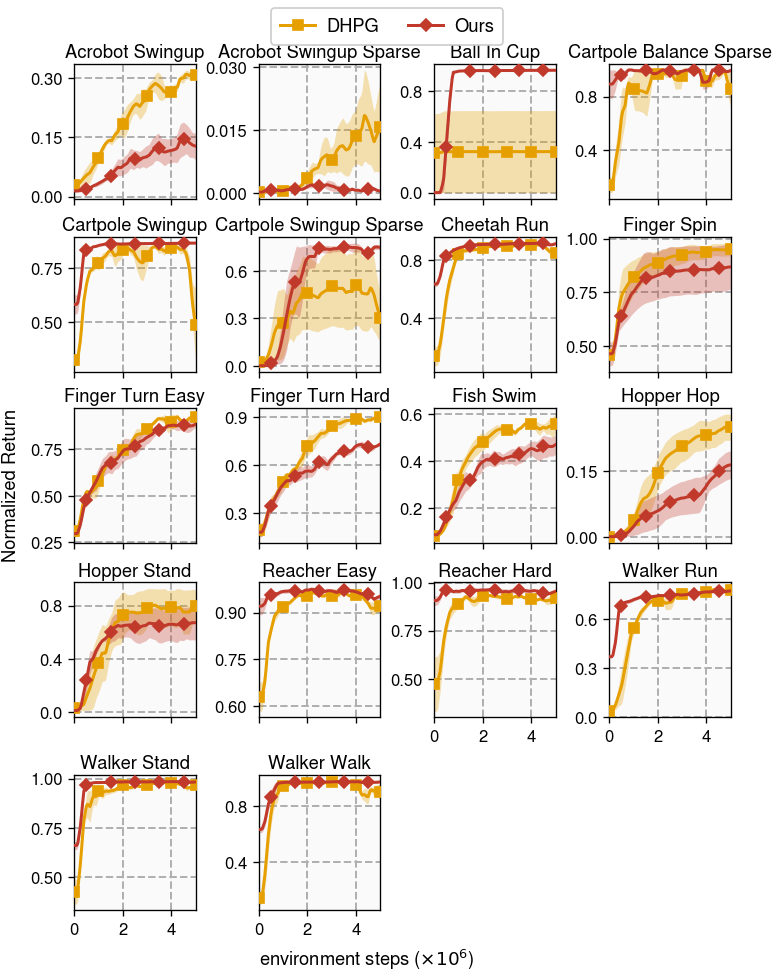

In [7]:
GRID = dict(
    # ---- which panels, and in what order -----------------------------------
    envs=None,              # None = all; or ["WalkerWalk", "CheetahRun", ...]
                            #   -- the list order IS the panel order
    titles=None,            # {"BallInCup": "Ball-in-Cup (sparse)"} to rename
    ncols=4,                # panels per row

    # ---- geometry, inches --------------------------------------------------
    panel_width=1.35,       # slot width per panel
    panel_height=1.45,      # slot height per panel
    extra_width=0.75,       # allowance for the shared y-label + tick labels
    extra_height=0.95,      # allowance for the x-label + legend
    w_pad=0.04,             # horizontal gap between panels
    h_pad=0.04,             # vertical gap between panels
    margin_left=0.0,
    margin_right=0.0,       # add ~0.5 to balance the y-label space on the left

    # ---- lines -------------------------------------------------------------
    line_width=1.8,
    marker_size=5.5,
    markers_per_curve=5,    # roughly how many markers each curve gets
    show_markers=True,
    band="sem",             # "sem" | "std" | "minmax" | None
    band_alpha=0.3,

    # ---- text sizes; None inherits the global style from args --------------
    title_size=None,        # per-panel titles
    tick_size=None,         # tick labels
    label_size=None,        # the shared x/y labels
    legend_size=None,

    # ---- axes --------------------------------------------------------------
    xlabel=None,            # None = "environment steps (x10^6)"
    ylabel=None,            # None = "Normalized <metric>"
    xlim=None,              # (lo, hi); None = (0, last step)
    ylim=None,              # (0, 1) for every panel, or {"CheetahRun": (0, .8)}
    xticks=3,               # approximate tick counts
    yticks=None,            # None picks 3 or 4 based on panel_width
    sharey=False,
    logx=False,

    # ---- legend ------------------------------------------------------------
    legend="above",         # "above" (framed, floating) | "inside" | None
    legend_ncol=None,       # None = one row, up to 4
    legend_loc="lower right",   # only used when legend="inside"
)

fig = rc.fig_grid(curves, frames, tasks, algos, labels, colors, markers,
                  tag=tag, **GRID)

Overrides for one-off variants — pass anything on top of `GRID`:

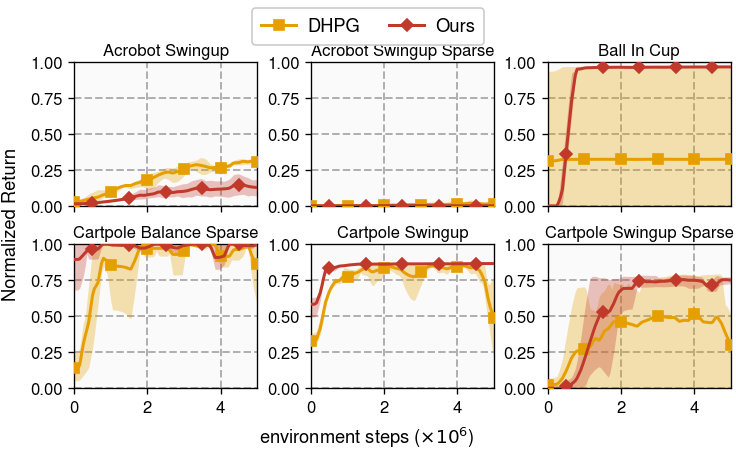

In [8]:
# a compact 3-wide figure of just the environments you want to highlight
fig = rc.fig_grid(
    curves, frames, tasks, algos, labels, colors, markers, tag=tag,
    **{**GRID,
       "envs": tasks[:6],
       "ncols": 3,
       "panel_width": 1.8,
       "ylim": (0, 1),
       "band": "minmax",
       "title_size": 10,
       "legend_ncol": 2},
)

### Colour scratchpad

Preview a palette before committing it to `color_overrides`.

(np.float64(0.0), np.float64(8.0), np.float64(-0.55), np.float64(0.55))

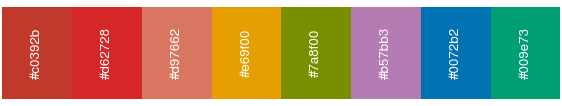

In [9]:
candidates = ["#c0392b", "#d62728", "#d97662", "#e69f00", "#7a8f00",
              "#b57bb3", "#0072b2", "#009e73"]
fig, ax = plt.subplots(figsize=(6, 1.1))
for i, hexcode in enumerate(candidates):
    ax.barh(0, 1, left=i, color=hexcode, height=1)
    ax.text(i + 0.5, 0, hexcode, ha="center", va="center",
            fontsize=8, color="white", rotation=90)
ax.set_xlim(0, len(candidates)); ax.axis("off")

## 6. Other metrics, one algorithm

Two things to watch when you leave `Eval/Return` behind:

* **Normalization.** `max_score=1000` is a DMC return convention and means
  nothing for a Q-value or a distance. `load_series` sets it to 1 and keeps
  raw units.
* **Pooling across environments.** `Q1_mean` runs to ~100 while
  `cross_state_action_distance` sits near 1-4, and both scales vary by
  environment. A raw average across environments would just track whichever
  environment has the largest numbers. `normalize="per_env_minmax"` maps each
  environment to [0, 1] first, so the aggregate describes *shape* -- how fast
  each quantity rises and where it settles -- not magnitude.

`load_series` returns both: `series` (normalized, for pooling) and `raw`
(untouched, for per-environment panels). Both are `{label: (runs, tasks,
frames)}`, the same shape `fig_grid` already takes, so every knob from section
5 applies.

In [15]:
METRICS = [
    ("Metric/cross_state_action_distance", "state-action distance"),
    ("Metric/cross_state_distance", "state distance"),
    ("SAC/Q1_mean", "Q1 mean"),
]
ONLY = ["algo3"]        # one algorithm; list two and labels become "metric (algo)"

series, raw, m_frames, m_tasks = rc.load_series(
    args, METRICS, algos=ONLY, normalize="none")

names = list(series)
m_labels = {k: k for k in names}
m_colors, m_markers = rc.style_map(names, args)
print(names, series[names[0]].shape)

['state-action distance', 'state distance', 'Q1 mean'] (3, 18, 101)


### Per environment, both metrics on a shared scale

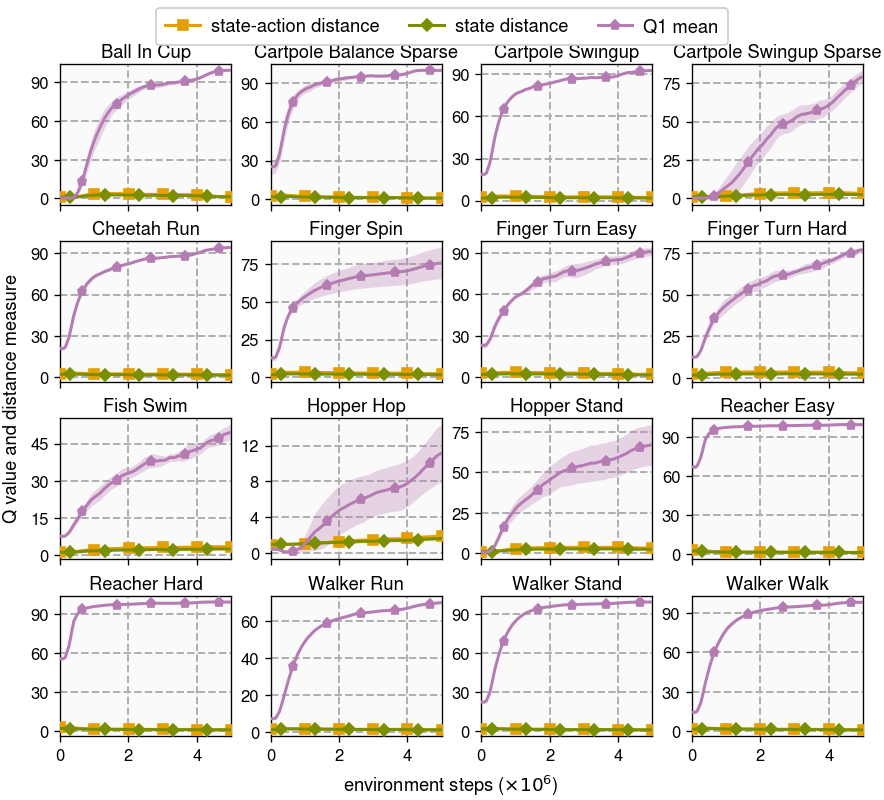

In [24]:
fig = rc.fig_grid(
    series, m_frames, m_tasks, names, m_labels, m_colors, m_markers,
    **{**GRID,
       "envs":tasks[2:],
       "ncols": 4,
       "panel_width": 1.7,
       "ylabel": "Q value and distance measure",
       "legend_ncol": 3,
       "margin_right": 0.3},
)

### Per environment, raw units

Normalizing hides magnitude, so plot each metric on its own when the actual
numbers matter. `sharey=False` lets every panel find its own range.

In [ ]:
which = "Q1 mean"        # or "cross state-action distance"
fig = rc.fig_grid(
    {which: raw[which]}, m_frames, m_tasks, [which], {which: which},
    m_colors, m_markers,
    **{**GRID, "ncols": 3, "panel_width": 1.7, "ylabel": f"{which} (raw)",
       "sharey": False, "legend": None},
)

### Marginalized over environments

IQM across the 3 seeds x N environments at each step, with stratified bootstrap
CIs -- the same estimator as the return figure, applied to the normalized
series.

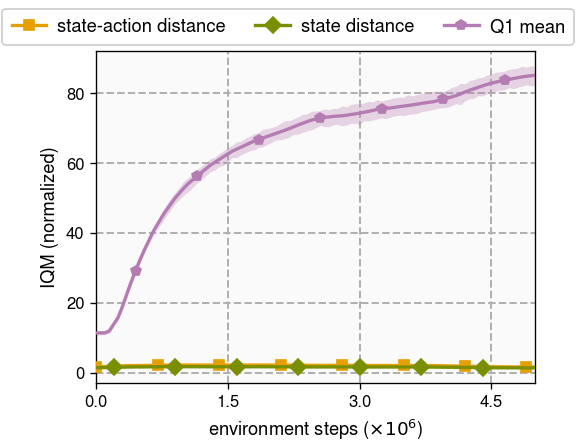

In [25]:
m_iqm, m_cis = rly.get_interval_estimates(
    series, rc.iqm_over_frames, reps=max(args.reps // 10, 200))

# fig_sample_efficiency already draws the framed legend above the axes, so
# don't add an axes-level one here (it would render as an empty box)
fig = rc.fig_sample_efficiency(m_frames, m_iqm, m_cis, names, m_labels,
                               m_colors, m_markers, args, "value")
fig.axes[0].set_ylabel("IQM (normalized)")   # keep it short: the panel is narrow
fig.set_figheight(3.8)
fig.set_figwidth(4.2)

### Showing that one settles earlier

A linear step axis crushes the first million steps into a sliver, which is
exactly where the difference is. `logx=True` expands it. Note the axis then
shows raw step counts rather than the `(x10^6)` factoring -- on a log scale
that factoring would print ticks as `10^-1`, `10^0`.

In [ ]:
fig = rc.fig_sample_efficiency(m_frames, m_iqm, m_cis, names, m_labels,
                               m_colors, m_markers, args, "value", logx=True)
fig.axes[0].set_ylabel("IQM (normalized)")

In [ ]:
fig = rc.fig_grid(
    series, m_frames, m_tasks, names, m_labels, m_colors, m_markers,
    **{**GRID, "ncols": 3, "panel_width": 1.7, "logx": True,
       "ylabel": "per-env normalized value", "legend_ncol": 2,
       "margin_right": 0.3},
)

### Putting a number on it

Curves are suggestive; a reviewer will want the gap quantified.
`settling_steps` reports, for each run, the first step at which the quantity
reaches a given fraction of its own final level. Progress is measured relative
to each run's own start and end, so it works whether the quantity rises or
falls, and it never depends on the two metrics sharing units.

In [ ]:
settle = rc.settling_steps(series, m_frames, m_tasks, frac=0.9)
summary = rc.settling_summary(settle, frac=0.9)
display(summary.round(0))

ratio = summary["median"].max() / summary["median"].min()
pairs = int(settle.groupby("series").size().iloc[0])
print(f"slowest settles {ratio:.1f}x later than the fastest "
      f"(median over {pairs} run-environment pairs)")

# per-environment breakdown, to check the effect is not driven by one env
settle.pivot_table(index="env", columns="series", values="step",
                   aggfunc="median")

`frac=0.9` is a choice, not a fact -- re-run with 0.8 and 0.95 and report
a value the ordering is stable under. If a run never reaches the threshold it
lands in `n_missing` rather than silently distorting the median.

### Log-domain normalization

Distinct from the log *axis* above. `normalize="per_env_log"` min/maxes each
environment in log10 space, which is what you want when the values themselves
span decades within an environment -- it keeps early small values from being
flattened to zero by a linear min/max.

In [ ]:
log_series, _, l_frames, l_tasks = rc.load_series(
    args, METRICS, algos=ONLY, normalize="per_env_log")

l_iqm, l_cis = rly.get_interval_estimates(
    log_series, rc.iqm_over_frames, reps=max(args.reps // 10, 200))
fig = rc.fig_sample_efficiency(l_frames, l_iqm, l_cis, names, m_labels,
                               m_colors, m_markers, args, "value", logx=True)
fig.axes[0].set_ylabel("IQM (log-normalized)")

Other `normalize` options: `"per_env_max"` divides by each environment's
own maximum and keeps zero fixed (better when zero is meaningful, as for a
distance); `"per_env_final"` divides by the mean final value, so everything
converges to 1 and the curves compare rates of approach; `"per_env_log"`
min/maxes in log10 space; `"none"` keeps raw units and should only be pooled if the metric is already comparable across
environments.

## 7. Save

Writes the same filenames the CLI produces, into `args.out_dir`. Note the
figure objects above were displayed, not closed, so this re-renders them.

In [ ]:
import os
os.makedirs(args.out_dir, exist_ok=True)
written = []

written += rc.save(
    rc.fig_aggregate_metrics(agg_scores, agg_cis, algos, labels, colors,
                             markers, args, tag),
    args.out_dir, f"aggregate_metrics_{tag}", args.formats)
written += rc.save(
    rc.fig_sample_efficiency(frames, iqm_scores, iqm_cis, algos, labels,
                             colors, markers, args, tag),
    args.out_dir, f"sample_efficiency_{tag}", args.formats)
written += rc.save(
    rc.fig_performance_profile(prof, prof_cis, taus, algos, labels,
                               colors, markers, args, tag),
    args.out_dir, f"performance_profile_{tag}", args.formats)
if poi_rows:
    written += rc.save(
        rc.fig_probability_of_improvement(poi_rows, labels, colors, markers, args),
        args.out_dir, f"probability_of_improvement_{tag}", args.formats)

g = rc.fig_grid(curves, frames, tasks, algos, labels, colors, markers,
                tag=tag, **GRID)
# margins are reserved inside the figure, so don't let tight bbox crop them away
written += rc.save(g, args.out_dir, f"per_env_curves_{tag}", args.formats,
                   tight=not (GRID["margin_left"] or GRID["margin_right"]))

for path in written:
    print(path)

In [ ]:
# LaTeX table of the aggregate metrics, ready to \input
rows = [dict(algorithm=a, metric=name, point=agg_scores[a][k],
             ci_low=agg_cis[a][0, k], ci_high=agg_cis[a][1, k])
        for a in algos for k, name in enumerate(rc.AGG_NAMES)]
tex_path = os.path.join(args.out_dir, f"aggregate_metrics_{tag}.tex")
rc.write_latex_table(pd.DataFrame(rows), algos, labels, tex_path)
print(open(tex_path).read())

## 8. Everything else

To run the whole pipeline exactly as the CLI does, including all the CSV and
JSON side outputs:

```python
rc.run_analysis(final, curves, frames, tasks, args)
```

Or from a shell, with the settings you converged on here:

```bash
python rliable_compare.py --logs-dir logs_fresh --envs all --smooth 3 \
    --algos dhpg_fix2 algo3 \
    --label algo3="Ours" --label dhpg_fix2="DHPG" \
    --color algo3='#c0392b' \
    --grid-cols 4 --margin-right 0.55
```

### Knob reference

Three levels of control, from broad to narrow:

1. **`args` + `rc.setup_style(args)`** — defaults for every figure: font family
   and size, palette, line width, grid, panel background. Section 2.
2. **`GRID` / per-figure keywords** — anything about the grid figure, without
   touching the globals. Section 5.
3. **the returned `fig`** — plain matplotlib after the fact:
   `fig.axes[0].set_ylim(0, 1)`, `fig.axes[2].set_title("...")`,
   `fig.set_size_inches(7, 4)`.

| Want to change | Where |
|---|---|
| Display name | `labels`, section 2 |
| Legend / row order | `algos` — first entry is leftmost |
| A colour | `color_overrides`, section 2 |
| Panels per row | `GRID["ncols"]` |
| Size of each subplot | `GRID["panel_width"]`, `GRID["panel_height"]` |
| Gap between subplots | `GRID["w_pad"]`, `GRID["h_pad"]` |
| Which panels, and their order | `GRID["envs"]` |
| Panel titles | `GRID["titles"]` |
| Font size, whole figure | `font_size` in section 2, then re-run `setup_style` |
| Font size, one element | `GRID["title_size"]`, `["tick_size"]`, `["label_size"]`, `["legend_size"]` |
| Line thickness, marker size | `GRID["line_width"]`, `["marker_size"]` |
| Band meaning and opacity | `GRID["band"]`, `["band_alpha"]` |
| Axis ranges / tick counts | `GRID["ylim"]`, `["xlim"]`, `["yticks"]`, `["xticks"]` |
| Legend placement | `GRID["legend"]`, `["legend_ncol"]`, `["legend_loc"]` |
| Whitespace at the edges | `GRID["margin_left"]`, `["margin_right"]` |
| Defaults for the *other* figures | `rc.setup_style`, lines ~100-135 of the script |
